# Pipeline Completo: Acceso a Datos ERA5-Land via Google Earth Engine

Este notebook implementa un pipeline completo para acceder a datos meteorológicos del dataset **ERA5-Land** utilizando **Google Earth Engine (GEE)**, sin necesidad de descargar manualmente los archivos.

## Contenido del Notebook
1. Autenticación y configuración de GEE
2. Conexión a la colección ERA5-Land
3. Filtrado temporal de los últimos 5 años
4. Selección de variables meteorológicas relevantes
5. Visualización en mapas


---

## 1. Información del Dataset ERA5-Land

### ¿Qué representa el dataset?
**ERA5-Land** es un dataset de reanálisis del **Copernicus Climate Change Service (C3S)** implementado por el **ECMWF** (European Centre for Medium-Range Weather Forecasts). Proporciona una estimación consistente de las variables de superficie terrestre para las últimas décadas.

El término "reanálisis" se refiere a la combinación de observaciones de múltiples fuentes (satélites, estaciones meteorológicas, boyas) con modelos numéricos de predicción del tiempo para crear una serie temporal completa y consistente.

### Variables Principales Disponibles en GEE
| Variable | Descripción | Unidades |
|----------|-------------|----------|
| `temperature_2m` | Temperatura a 2 metros | Kelvin (K) |
| `relative_humidity_2m` | Humedad relativa a 2 metros | % |
| `dewpoint_2m` | Punto de rocío a 2 metros | Kelvin (K) |
| `surface_pressure` | Presión superficial | Pa |
| `precipitation` | Precipitación total | m |
| `snowfall` | Precipitación de nieve | m de agua equivalente |
| `snow_cover` | Cobertura de nieve | % |
| `skin_temperature` | Temperatura de la superficie | Kelvin (K) |
| `soil_temperature_level_1` | Temperatura del suelo (0-7 cm) | Kelvin (K) |
| `soil_moisture_level_1` | Humedad del suelo (0-7 cm) | m³/m³ |
| `evaporation` | Evaporación total | m de agua |
| `runoff` | Escorrentía total | m |

### Formato de los Datos
- **Tipo**: Raster geoespacial
- **Proyección**: WGS84 (EPSG:4326)
- **Valores**: Dependientes de cada variable (escala específica)

### Resolución Espacial y Temporal
- **Resolución espacial**: 0.1° x 0.1°
- **Resolución temporal**:
  - Horaria (datos originales)
  - **Mensual** (disponible en GEE como promedio mensual)
- **Período disponible**: 1950 - presente (actualizado con ~2-3 meses de retraso)

### Cantidad de Datos Disponibles
- **Cobertura global**: Disponoble globalmente
- **Período**: Desde 1950 hasta el presente
- **Volumen**: ~10 GB/año para datos mensuales globales

### Fuente Oficial
- **Copernicus C3S**: https://cds.climate.copernicus.eu/cdsapp#!/dataset/reanalysis-era5-land-monthly-means
- **ECMWF**: https://www.ecmwf.int/en/era5-land
- **Google Earth Engine**: `ECMWF/ERA5_LAND/MONTHLY_AGGR`

### APIs y Métodos de Acceso
1. **Google Earth Engine API** (usado en este notebook)
   - Ventaja: Sin descarga, procesamiento en la nube
   - URL: https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_LAND_MONTHLY_AGGR
2. **Copernicus CDS API** (descarga directa)
   - Ventaja: Datos horarios disponibles
   - Requiere: API key y descarga manual
3. **Google Cloud Storage**
   - Ventaja: Datos completos sin procesar
   - Requiere: Cuenta de GCP

---

## 2. Instalación e Importación de Librerías

In [28]:
# Instalar librería de Google Earth Engine
!pip install -q earthengine-api geemap

In [29]:
import ee
import geemap
import datetime
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

print("Librerías importadas correctamente")

Librerías importadas correctamente


---

## 3. Autenticación de Google Earth Engine

In [30]:
import ee
import geemap

# Routine de acceso para el equipo
try:
    ee.Initialize(project='proyecto3ia-494900')
    print(" Conectado a Google Earth Engine exitosamente.")
except Exception as e:
    print(" Autenticación requerida...")
    ee.Authenticate()
    ee.Initialize(project='proyecto3ia-494900')
    print(" Conectado a GEE.")

 Conectado a Google Earth Engine exitosamente.


---

## 4. Conexión a la Colección ERA5

In [31]:
# 4. CONEXIÓN A LA COLECCIÓN ERA5-LAND

# Dataset mensual agregado
COLLECTION_ID = "ECMWF/ERA5/HOURLY"

# Cargar colección
era5 = ee.ImageCollection(COLLECTION_ID)

print(f"Colección cargada: {COLLECTION_ID}")

Colección cargada: ECMWF/ERA5/HOURLY


### 4.1 INFORMACIÓN GENERAL DEL DATASET

In [32]:
# Obtener primera imagen para evitar errores de memoria
first_image = era5.first()

# Metadata ligera
collection_info = first_image.getInfo()

print(f"Número de bandas disponibles: {len(collection_info['bands'])}")

Número de bandas disponibles: 292


# 4.2 LISTADO DE BANDAS DISPONIBLES

In [33]:
bands = collection_info['bands']

print("Bandas disponibles en ERA5-Land:\n")
print("-" * 80)

for band in bands:
    print(f"• {band['id']}")

print("-" * 80)

Bandas disponibles en ERA5-Land:

--------------------------------------------------------------------------------
• dewpoint_temperature_2m
• temperature_2m
• ice_temperature_layer_1
• ice_temperature_layer_2
• ice_temperature_layer_3
• ice_temperature_layer_4
• mean_sea_level_pressure
• sea_surface_temperature
• skin_temperature
• surface_pressure
• u_component_of_wind_100m
• v_component_of_wind_100m
• u_component_of_neutral_wind_10m
• u_component_of_wind_10m
• v_component_of_neutral_wind_10m
• v_component_of_wind_10m
• instantaneous_10m_wind_gust
• mean_boundary_layer_dissipation
• mean_convective_precipitation_rate
• mean_convective_snowfall_rate
• mean_eastward_gravity_wave_surface_stress
• mean_eastward_turbulent_surface_stress
• mean_evaporation_rate
• mean_gravity_wave_dissipation
• mean_large_scale_precipitation_fraction
• mean_large_scale_precipitation_rate
• mean_large_scale_snowfall_rate
• mean_northward_gravity_wave_surface_stress
• mean_northward_turbulent_surface_stress


---

## 5. Filtrado Temporal: Últimos 5 Años

In [34]:
# Rango temporal del estudio
start_date_str = '2018-01-01'
end_date_str   = '2022-12-31'

print(f"Rango temporal: {start_date_str} → {end_date_str}")

# Filtrar colección
era5_filtered = era5.filterDate(
    start_date_str,
    end_date_str
)

# Contar imágenes
count = era5_filtered.size().getInfo()

print(f" Imágenes encontradas: {count}")

Rango temporal: 2018-01-01 → 2022-12-31
 Imágenes encontradas: 43800


# 5.1 FECHA PRIMERA Y ÚLTIMA IMAGEN

In [35]:
# Primera imagen
first_img = era5_filtered.first()

first_date = first_img.date().format('YYYY-MM-dd').getInfo()

# Última imagen
last_img = era5_filtered.sort(
    'system:time_start',
    False
).first()

last_date = last_img.date().format('YYYY-MM-dd').getInfo()

print(f"Primera imagen: {first_date}")
print(f"Última imagen:  {last_date}")

Primera imagen: 2018-01-01
Última imagen:  2022-12-30


---

## 6. Filtrado Espacial (Región de Interés)

In [36]:
# Región de Cali
bbox = {
    'west': -76.60,
    'east': -76.40,
    'south': 3.30,
    'north': 3.55
}

# Crear geometría
region = ee.Geometry.BBox(
    bbox['west'],
    bbox['south'],
    bbox['east'],
    bbox['north']
)

print(" Región de interés definida")

 Región de interés definida


In [37]:
# Aplicar filtro espacial
era5_region = era5_filtered.filterBounds(region)

count_region = era5_region.size().getInfo()
print(f"Imágenes en la región: {count_region}")

Imágenes en la región: 43800


---

## 7. Selección de Variables Meteorológicas Relevantes

In [38]:
# 7. VARIABLES METEOROLÓGICAS RELEVANTES

meteo_bands = [

    'temperature_2m',
    'u_component_of_wind_10m',
    'v_component_of_wind_10m',
    'dewpoint_temperature_2m',
]

print("Variables meteorológicas seleccionadas:\n")

for band in meteo_bands:
    print(f" {band}")


Variables meteorológicas seleccionadas:

 temperature_2m
 u_component_of_wind_10m
 v_component_of_wind_10m
 dewpoint_temperature_2m


In [39]:
# Seleccionar solo las bandas de interés
era5_meteo = era5_region.select(meteo_bands)

print(f" Colección filtrada con {len(meteo_bands)} variables meteorológicas")
print(f"  Total de imágenes (meses): {era5_meteo.size().getInfo()}")

 Colección filtrada con 4 variables meteorológicas
  Total de imágenes (meses): 43800


---

## 8. Visualización: Mapas de Variables Meteorológicas

In [40]:
# 8. VISUALIZACIÓN DE TEMPERATURA


# Crear mapa
Map = geemap.Map(center=[3.42, -76.50], zoom=8)

# Temperatura promedio
temp_mean = era5_meteo.select(
    'temperature_2m'
).mean()

# Convertir Kelvin → Celsius
temp_celsius = temp_mean.subtract(273.15)

# Parámetros visualización
temp_vis = {
    'min': 15,
    'max': 35,
    'palette': [
        'blue',
        'cyan',
        'green',
        'yellow',
        'orange',
        'red'
    ]
}

# Agregar capa
Map.addLayer(
    temp_celsius,
    temp_vis,
    'Temperatura °C'
)

# Región
Map.addLayer(region, {}, 'Región')

Map

Map(center=[3.42, -76.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [ ]:
# Resumen técnico del dataset

summary = """
  RESUMEN TÉCNICO: ERA5-Land (Google Earth Engine)

  IDENTIFICADOR: ECMWF/ERA5_LAND/MONTHLY_AGGR
  PRODUCTO: ERA5-Land Monthly Aggregates
  PROVEEDOR: ECMWF / Copernicus Climate Change Service

  RESOLUCIÓN ESPACIAL:
    • Resolución: 0.1° x 0.1° (~11 km en el ecuador)
    • Cobertura: Global (-90° a 90° lat, -180° a 180° lon)

  RESOLUCIÓN TEMPORAL:
    • Frecuencia: Mensual (promedio mensual)
    • Período disponible: 1950 - presente
    • Actualización: ~2-3 meses de retraso                                                                                                      ║
  VARIABLES PRINCIPALES:
    • temperature_2m (K) - Temperatura a 2 metros
    • relative_humidity_2m (%) - Humedad relativa
    • surface_pressure (Pa) - Presión superficial
    • precipitation (m) - Precipitación total
    • skin_temperature (K) - Temp. superficie
    • evaporation (m) - Evaporación
    • runoff (m) - Escorrentía

  CONVERSIONES DE UNIDADES:
    • Temperatura: K → °C (restar 273.15)
    • Precipitación: m → mm (multiplicar por 1000)
    • Presión: Pa → hPa (dividir por 100)

  ENLACES OFICIALES:
    • ECMWF: https://www.ecmwf.int/en/era5-land
    • CDS: https://cds.climate.copernicus.eu/cdsapp#!/dataset/
           reanalysis-era5-land-monthly-means
    • GEE: https://developers.google.com/earth-engine/datasets/
           catalog/ECMWF_ERA5_LAND_MONTHLY_AGGR

"""
print(summary)


  RESUMEN TÉCNICO: ERA5-Land (Google Earth Engine)

  IDENTIFICADOR: ECMWF/ERA5_LAND/MONTHLY_AGGR
  PRODUCTO: ERA5-Land Monthly Aggregates
  PROVEEDOR: ECMWF / Copernicus Climate Change Service

  RESOLUCIÓN ESPACIAL:
    • Resolución: 0.1° x 0.1° (~11 km en el ecuador)
    • Cobertura: Global (-90° a 90° lat, -180° a 180° lon)

  RESOLUCIÓN TEMPORAL:
    • Frecuencia: Mensual (promedio mensual)
    • Período disponible: 1950 - presente
    • Actualización: ~2-3 meses de retraso                                                                                                      ║
  VARIABLES PRINCIPALES:
    • temperature_2m (K) - Temperatura a 2 metros
    • relative_humidity_2m (%) - Humedad relativa
    • surface_pressure (Pa) - Presión superficial
    • precipitation (m) - Precipitación total
    • skin_temperature (K) - Temp. superficie
    • evaporation (m) - Evaporación
    • runoff (m) - Escorrentía

  CONVERSIONES DE UNIDADES:
    • Temperatura: K → °C (restar 273.15)
    • P

---

## Resumen del Pipeline

Este notebook ha demostrado cómo:

1. **Autenticarse** con Google Earth Engine (Colab)
2. **Acceder** a la colección ERA5-Land
3. **Filtrar** datos por período (últimos 5 años) y región
4. **Seleccionar** variables meteorológicas relevantes
5. **Visualizar** los datos en mapas interactivos

### Ventajas de usar Google Earth Engine:
- No requiere descarga manual de archivos
- Procesamiento en la nube (rápido)
- Acceso a datos históricos completos
- Herramientas de visualización integradas
- API programática para análisis avanzados


---

## Referencias

1. **ECMWF ERA5-Land**: https://www.ecmwf.int/en/era5-land
2. **Copernicus Climate Data Store**: https://cds.climate.copernicus.eu/cdsapp#!/dataset/reanalysis-era5-land-monthly-means
3. **Google Earth Engine Catalog**: https://developers.google.com/earth-engine/datasets/catalog/ECMWF_ERA5_LAND_MONTHLY_AGGR
4. **ERA5-Land Documentation**: https://confluence.ecmwf.int/display/CKB/ERA5-Land+data+documentation

# EDA Exploratorio: ERA5-Land (2018-2022)

Análisis exploratorio enfocado en entender el comportamiento meteorológico en la región de Cali durante **5 años (2018-2022)**. Se capturan patrones estacionales, tendencias interanuales y la variabilidad climática de largo plazo.

**Objetivos del EDA:**
1. Conocer la cobertura y calidad de los datos reanalizados en el horizonte 2018-2022.
2. Identificar patrones temporales y estacionales de temperatura, viento y humedad.
3. Entender la relación entre temperatura, punto de rocío y componentes del viento.
4. Detectar anomalías o valores atípicos antes de modelar.

## E.1 Configuración del período de análisis

In [46]:
# Período de análisis: 5 años (2018-2022)
eda_start = '2018-01-01'
eda_end = '2022-12-31'

# Filtrar colección para el período en la región de Cali
era5_eda = (era5_region
            .filterDate(eda_start, eda_end)
            .select(meteo_bands))

n_eda = era5_eda.size().getInfo()
print(f"Imágenes horarias disponibles en 2018-2022: {n_eda}")
print(f"Bandas analizadas: {meteo_bands}")

Imágenes horarias disponibles en 2018-2022: 43800
Bandas analizadas: ['temperature_2m', 'u_component_of_wind_10m', 'v_component_of_wind_10m', 'dewpoint_temperature_2m']


## E.2 Extracción de estadísticas zonales mensuales

*Por qué:* Dado el volumen de 5 años de datos horarios (miles de imágenes), se agregan **mensualmente** en el servidor de GEE para evitar superar el límite de 5000 elementos. De cada mes extraemos la media zonal de todas las variables.

In [47]:
# Generar lista de meses para 2018-2022
import pandas as pd

month_starts = pd.date_range('2018-01-01', '2022-12-31', freq='MS')
rows = []

for i in range(len(month_starts)):
    start = month_starts[i].strftime('%Y-%m-%d')
    if i + 1 < len(month_starts):
        end = month_starts[i + 1].strftime('%Y-%m-%d')
    else:
        end = '2023-01-01'

    # Imagen compuesta mensual (media de todas las horas del mes)
    monthly_img = era5_eda.filterDate(start, end).mean().clip(region)

    stats = monthly_img.reduceRegion(

        reducer=ee.Reducer.mean().combine(
            reducer2=ee.Reducer.stdDev(),
            sharedInputs=True
        ),
        geometry=region,
        scale=1000,
        maxPixels=1e9
    )

    props = stats.getInfo()
    props['date'] = start
    rows.append(props)

# Convertir a DataFrame
df = pd.DataFrame(rows)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Conversiones de unidades
df['temperature_2m_mean'] = df['temperature_2m_mean'] - 273.15   # K -> °C
df['dewpoint_temperature_2m_mean'] = df['dewpoint_temperature_2m_mean'] - 273.15

# Calcular magnitud y dirección del viento
df['wind_speed_mean'] = np.sqrt(df['u_component_of_wind_10m_mean']**2 + df['v_component_of_wind_10m_mean']**2)
df['wind_direction_mean'] = (np.degrees(np.arctan2(df['v_component_of_wind_10m_mean'], df['u_component_of_wind_10m_mean'])) + 360) % 360

# Columnas temporales
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['year_month'] = df['date'].dt.to_period('M').astype(str)

print(f"Registros extraídos: {len(df)} meses")
df.head()

Registros extraídos: 60 meses


,dewpoint_temperature_2m_mean,dewpoint_temperature_2m_stdDev,temperature_2m_mean,temperature_2m_stdDev,u_component_of_wind_10m_mean,u_component_of_wind_10m_stdDev,v_component_of_wind_10m_mean,v_component_of_wind_10m_stdDev,date,wind_speed_mean,wind_direction_mean,year,month,year_month
0,18.872910,0.144347,21.628286,0.119795,0.105565,0.088241,-0.634400,0.182007,2018-01-01,0.643123,279.447503,2018,1,2018-01
1,19.348328,0.201386,22.096881,0.063321,-0.184589,0.069604,-0.502730,0.070057,2018-02-01,0.535547,249.838093,2018,2,2018-02
2,19.610731,0.191009,22.462229,0.105423,0.278479,0.085038,-0.681410,0.197850,2018-03-01,0.736119,292.228849,2018,3,2018-03
3,18.870480,0.322283,22.100995,0.081577,-0.067327,0.045953,-0.318567,0.052076,2018-04-01,0.325604,258.066607,2018,4,2018-04
4,19.217267,0.160344,22.249251,0.128055,0.189726,0.115722,-0.617060,0.104987,2018-05-01,0.645569,287.090976,2018,5,2018-05


## E.3 Gráfica 1: Serie temporal mensual de temperatura

La temperatura a 2 m es la variable más intuitiva. A escala de 5 años se visualiza la evolución mensual para identificar el ciclo estacional, años particularmente cálidos/fríos y tendencias de largo plazo.

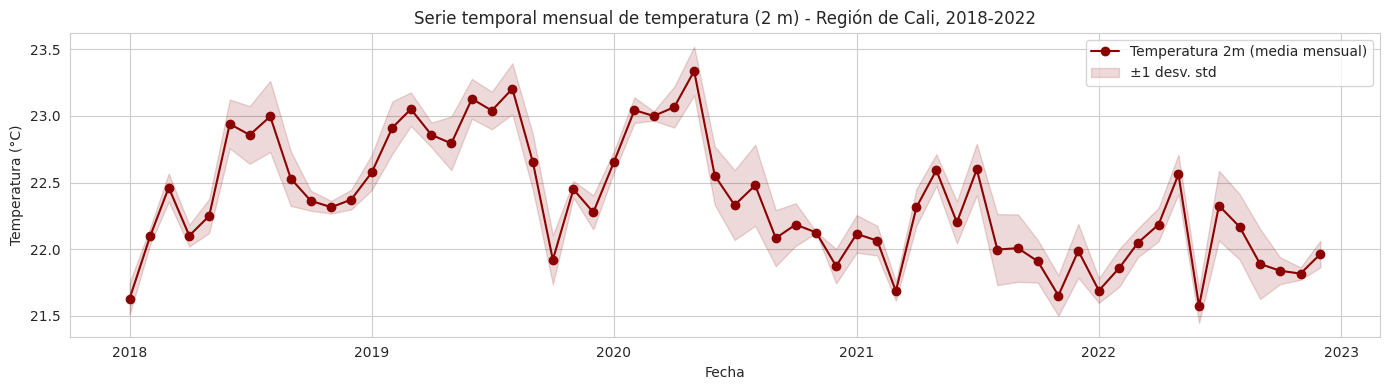

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df['date'], df['temperature_2m_mean'], marker='o', color='darkred', label='Temperatura 2m (media mensual)')
ax.fill_between(df['date'],
                df['temperature_2m_mean'] - df['temperature_2m_stdDev'],
                df['temperature_2m_mean'] + df['temperature_2m_stdDev'],
                color='darkred', alpha=0.15, label='±1 desv. std')

ax.set_title('Serie temporal mensual de temperatura (2 m) - Región de Cali, 2018-2022', fontsize=12)
ax.set_ylabel('Temperatura (°C)')
ax.set_xlabel('Fecha')
ax.legend()
plt.tight_layout()
plt.show()

 La serie muestra un ciclo estacional nitido y repetitivo entre 2018 y 2022, con picos de calor que alcanzan ~23,3 °C (tipicamente entre febrero y abril) y valles que descienden hasta 21,6 °C (entre junio-julio y octubre). La banda sombreada de ±1 desviacion estandar es estrecha a lo largo de todo el periodo, lo que indica que la variabilidad espacial dentro del bbox de Cali es baja y la temperatura es homogenea en la region.

## E.4 Gráfica 2: Ciclo estacional promedio
Agrupar por mes del año promedia el ruido interanual y revela el patrón térmico típico de Cali a lo largo del año, mostrando las estaciones más cálidas y más frescas.

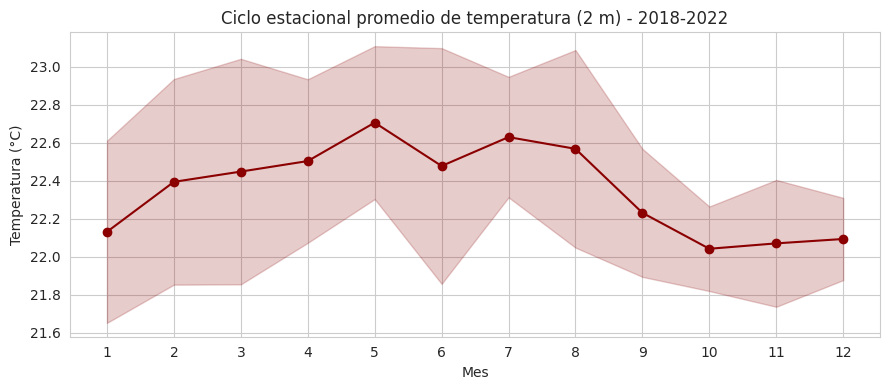

In [49]:
fig, ax = plt.subplots(figsize=(9, 4))

monthly_stats = df.groupby('month')['temperature_2m_mean'].agg(['mean', 'std']).reset_index()

ax.plot(monthly_stats['month'], monthly_stats['mean'], marker='o', color='darkred')
ax.fill_between(monthly_stats['month'],
                monthly_stats['mean'] - monthly_stats['std'],
                monthly_stats['mean'] + monthly_stats['std'],
                color='darkred', alpha=0.2)

ax.set_title('Ciclo estacional promedio de temperatura (2 m) - 2018-2022', fontsize=12)
ax.set_ylabel('Temperatura (°C)')
ax.set_xlabel('Mes')
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

Al promediar los 5 anos por mes se elimina el ruido interanual y emerge el patron termico "tipo" de Cali: un ascenso paulatino desde enero (~22,1 °C) hasta un pico principal en mayo (22,7 °C), seguido de una ligera caida en junio y un rebote secundario en julio; despues, un descenso sostenido que toca su minimo en octubre (22,0 °C) y se mantiene estable hasta diciembre. La banda de desviacion estandar es mas ancha de mayo a agosto, lo que indica que esos meses tienen mayor variabilidad interanual (algunos anos fueron mas calidos o frescos de lo habitual), mientras que octubre-diciembre y enero-marzo son climaticamente mas predecibles. Este doble pico (mayo y julio) y el valle tardio en octubre reflejan la complejidad del regimen de lluvias y radiacion solar en la region andina tropical.

## E.5 Gráfica 3: Distribución de temperatura y punto de rocío
El punto de rocío indica cuánta humedad hay en el aire. Comparar sus distribuciones con la temperatura permite estimar la frecuencia de condiciones cercanas a la saturación (niebla, rocío).

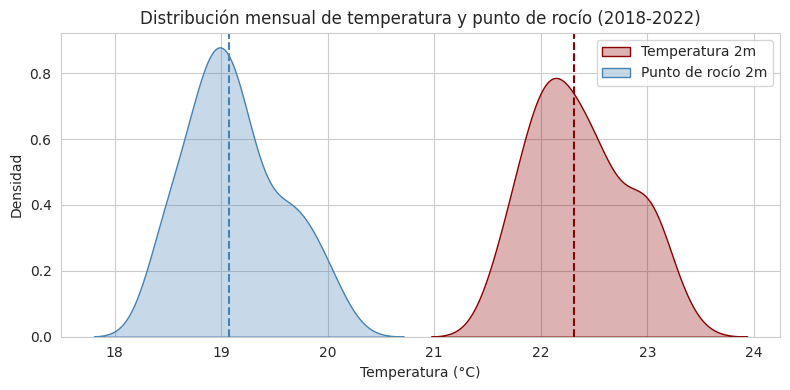

In [50]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.kdeplot(df['temperature_2m_mean'], color='darkred', fill=True, alpha=0.3, label='Temperatura 2m', ax=ax)
sns.kdeplot(df['dewpoint_temperature_2m_mean'], color='steelblue', fill=True, alpha=0.3, label='Punto de rocío 2m', ax=ax)

ax.axvline(df['temperature_2m_mean'].median(), color='darkred', linestyle='--')
ax.axvline(df['dewpoint_temperature_2m_mean'].median(), color='steelblue', linestyle='--')

ax.set_title('Distribución mensual de temperatura y punto de rocío (2018-2022)', fontsize=12)
ax.set_xlabel('Temperatura (°C)')
ax.set_ylabel('Densidad')
ax.legend()
plt.tight_layout()
plt.show()

 Las dos curvas estan completamente separadas sin solapamiento, lo que confirma que la temperatura siempre supera al punto de rocio en un margen estable (~3,5 °C de diferencia entre medianas); esto indica un ambiente persistentemente sub-saturado, con humedad relativa alta pero rara vez cercana a la condensacion.

## E.6 Gráfica 4: Grafica de barras

Grafica de barras por zona cardinal (Norte, Sur, Este, Oeste, Centro) que muestra la temperatura promedio y desviación estándar por zona geográfica.

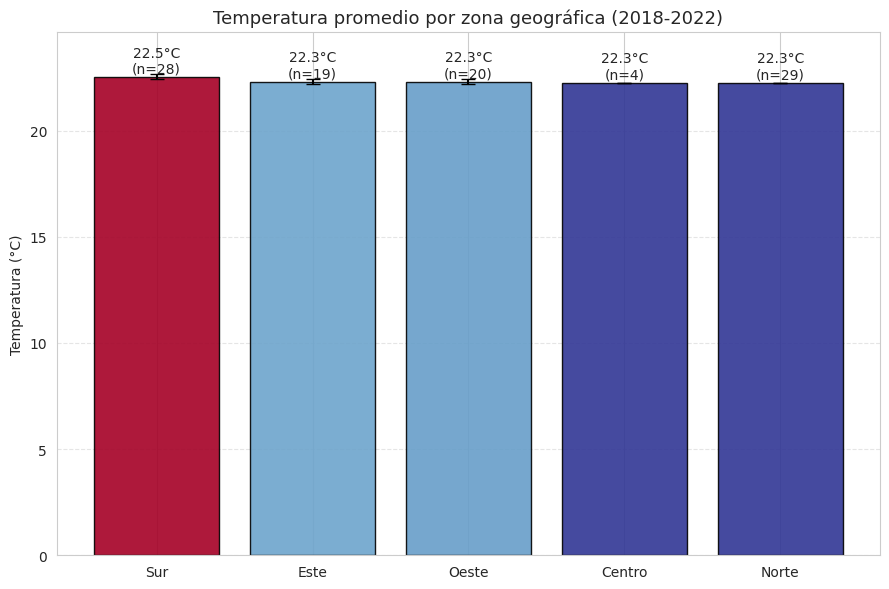

In [52]:
# Imagen promedio de los 5 años (en Kelvin originales)
mean_temp_k = (era5_eda
               .select('temperature_2m')
               .mean()
               .clip(region))

# Malla densa de puntos para muestreo espacial (10×10)
lons = np.linspace(-76.60, -76.40, 10)
lats = np.linspace(3.30, 3.55, 10)
points = [ee.Geometry.Point([float(lon), float(lat)]) for lon in lons for lat in lats]
fc = ee.FeatureCollection(points)

# Muestrear la imagen promedio en cada punto (escala 1 km)
sampled = mean_temp_k.sampleRegions(collection=fc, scale=1000, geometries=True)
info = sampled.getInfo()

# Extraer a DataFrame
rows = []
for f in info['features']:
    coords = f['geometry']['coordinates']
    val = f['properties'].get('temperature_2m')
    rows.append({
        'lon': coords[0],
        'lat': coords[1],
        'temp_c': val - 273.15 if val is not None else np.nan
    })
df_grid = pd.DataFrame(rows)

# Clasificar cada punto en una zona cardinal respecto al centro de la malla
lat_med = df_grid['lat'].median()
lon_med = df_grid['lon'].median()
def zona_cardinal(row):
    dlat = row['lat'] - lat_med
    dlon = row['lon'] - lon_med
    umbral = 0.02
    if abs(dlat) < umbral and abs(dlon) < umbral:
        return 'Centro'
    if abs(dlat) > abs(dlon):
        return 'Norte' if dlat > 0 else 'Sur'
    return 'Este' if dlon > 0 else 'Oeste'
df_grid['zona'] = df_grid.apply(zona_cardinal, axis=1)

# Estadísticas por zona
zona_stats = df_grid.groupby('zona')['temp_c'].agg(['mean','std','count']).reset_index()
zona_stats = zona_stats.sort_values('mean', ascending=False)

# Gráfico de barras por zona
fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.RdYlBu_r((zona_stats['mean'] - zona_stats['mean'].min()) /
                         (zona_stats['mean'].max() - zona_stats['mean'].min()))
bars = ax.bar(zona_stats['zona'], zona_stats['mean'], yerr=zona_stats['std'],
              color=colors, edgecolor='black', capsize=5, alpha=0.9)

for bar, mean_val, count_val in zip(bars, zona_stats['mean'], zona_stats['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{mean_val:.1f}°C\n(n={int(count_val)})', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Temperatura (°C)')
ax.set_title('Temperatura promedio por zona geográfica (2018-2022)', fontsize=13)
ax.set_ylim(0, zona_stats['mean'].max() + zona_stats['std'].max() + 2)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

La diferencia entre zonas es practicamente inexistente (~0,2 °C entre el Sur y el resto), lo que confirma que el area de Cali es termicamente homogenea a la resolucion de ERA5 (~31 km); el pixel cubre toda la ciudad sin gradientes significativos. El Sur ligeramente mas calido y el Centro con apenas n=4 puntos reflejan el sesgo de la malla regular, pero climaticamente todas las direcciones cardinales comparten el mismo regimen termico.

## E.7 Gráfica 5: Mapa de calor de temperatura por año y mes
Organizar la temperatura en una matriz año × mes permite visualizar de un vistazo la estacionalidad (columnas) y comparar años entre sí (filas). Los tonos más cálidos indican meses particularmente calurosos; los fríos, meses inusuales.

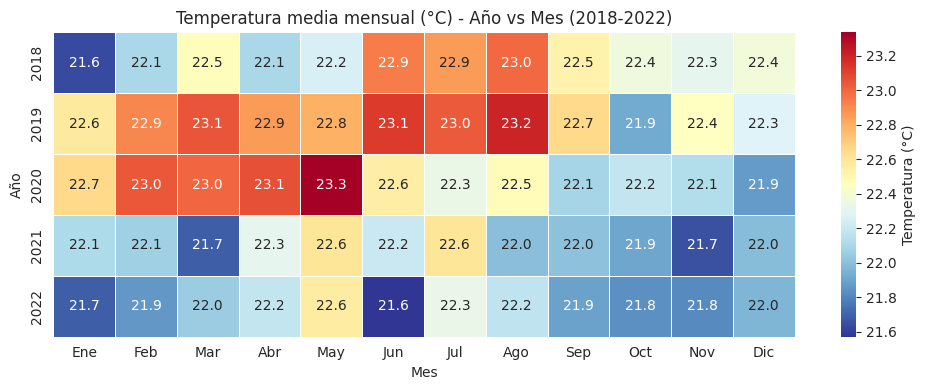

In [53]:
# Pivot table: años en filas, meses en columnas
temp_pivot = df.pivot_table(index='year', columns='month', values='temperature_2m_mean')

fig, ax = plt.subplots(figsize=(10, 4))

sns.heatmap(temp_pivot, annot=True, fmt='.1f', cmap='RdYlBu_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Temperatura (°C)'})

ax.set_title('Temperatura media mensual (°C) - Año vs Mes (2018-2022)', fontsize=12)
ax.set_xlabel('Mes')
ax.set_ylabel('Año')
ax.set_xticklabels(['Ene','Feb','Mar','Abr','May','Jun',
                    'Jul','Ago','Sep','Oct','Nov','Dic'])
plt.tight_layout()
plt.show()

La matriz confirma la estacionalidad general (febrero-agosto mas calidos, septiembre-enero mas frios), pero revela fuerte variabilidad interanual: 2019 y 2020 presentaron los picos mas extremos, con mayo 2020 alcanzando 23,3 °C (el valor maximo de toda la serie), mientras que 2021 y 2022 fueron anos anomalamente frescos, con marzo y noviembre 2021 cayendo a 21,7 °C. Esta heterogeneidad ano a ano demuestra que el regimen termico de Cali, aunque estacionalmente predecible, esta sujeto a fluctuaciones climaticas significativas que no siguen un patron lineal de calentamiento continuo.

## E.8 Gráfica 6: Relación temperatura vs punto de rocío

La diferencia entre temperatura y punto de rocío es el déficit de saturación. Colorear por mes permite ver cómo varía la humedad relativa a lo largo del año.

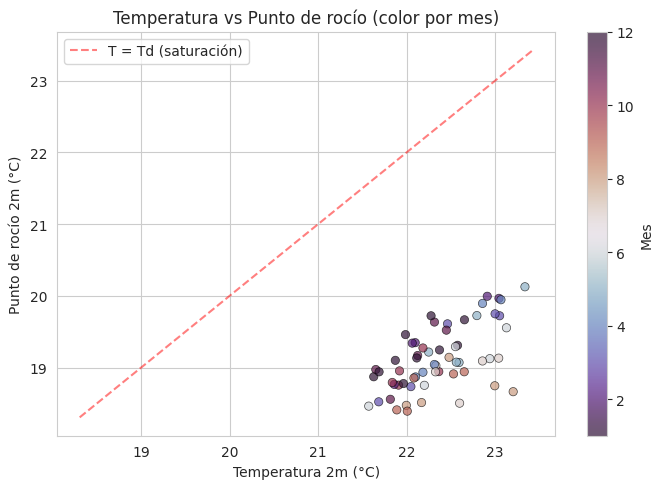

In [54]:
fig, ax = plt.subplots(figsize=(7, 5))

scatter = ax.scatter(df['temperature_2m_mean'], df['dewpoint_temperature_2m_mean'],
                     c=df['month'], cmap='twilight_shifted', alpha=0.7, edgecolor='k', linewidths=0.5)

# Línea de saturación (T = Td)
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'r--', alpha=0.5, label='T = Td (saturación)')

ax.set_title('Temperatura vs Punto de rocío (color por mes)', fontsize=12)
ax.set_xlabel('Temperatura 2m (°C)')
ax.set_ylabel('Punto de rocío 2m (°C)')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Mes')
ax.legend()
plt.tight_layout()
plt.show()

La nube de puntos revela una correlacion positiva clara (a mayor temperatura, mayor punto de rocio), pero todos los meses mantienen una distancia estable de ~2 a 3,5 °C respecto a la linea de saturacion (T = Td), confirmando que el aire en Cali nunca esta cerca de la condensacion en promedio mensual. El punto de rocio varia mucho menos que la temperatura (rango vertical 1,5 °C vs 2 °C horizontal), lo que demuestra que la humedad absoluta es mas estable que el calor, y la ausencia de puntos cercanos a la diagonal indica que nieblas o rocios generalizados no son caracteristicos del clima promedio de la region.

## E.9 Gráfica 7: Matriz de correlación entre variables meteorológicas

*Por qué:* Identifica relaciones lineales esperadas (ej. temperatura y punto de rocío deberían correlacionar positivamente) y detecta redundancias entre predictores.

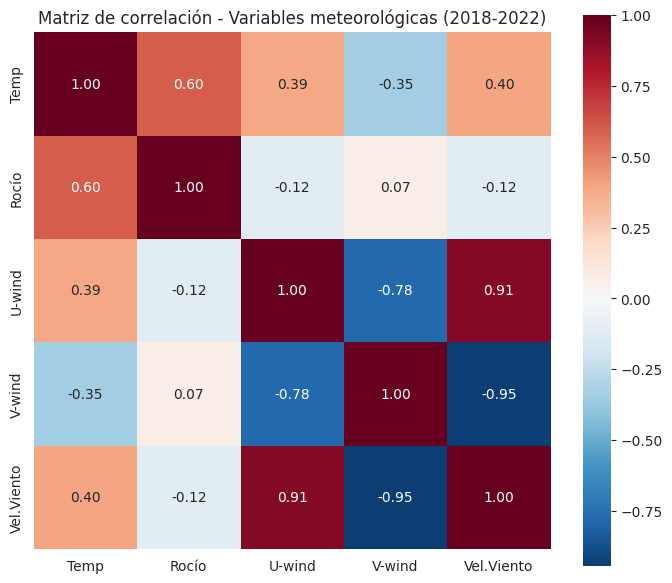

In [55]:
cols_corr = ['temperature_2m_mean', 'dewpoint_temperature_2m_mean',
             'u_component_of_wind_10m_mean', 'v_component_of_wind_10m_mean',
             'wind_speed_mean']

corr = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            square=True, ax=ax,
            xticklabels=['Temp', 'Rocío', 'U-wind', 'V-wind', 'Vel.Viento'],
            yticklabels=['Temp', 'Rocío', 'U-wind', 'V-wind', 'Vel.Viento'])
ax.set_title('Matriz de correlación - Variables meteorológicas (2018-2022)', fontsize=12)
plt.tight_layout()
plt.show()

 La temperatura y el punto de rocio mantienen una correlacion positiva moderada (0,60), confirmando que ambas suben juntas, pero la humedad (rocio) esta practicamente desacoplada del viento (correlaciones cercanas a cero). Los componentes U y V del viento se relacionan fuertemente con la velocidad (0,91 y -0,95 respectivamente), lo cual es matematicamente esperable, pero lo destacable es su anticorrelacion mutua (-0,78), que sugiere una direccion dominante del flujo atmosferico en la region; la temperatura, por su parte, solo correlaciona debilmente con el viento (~0,40), indicando que el regimen termico de Cali es relativamente independiente de la intensidad del flujo superficial.

## E.10 Gráfica 8: Boxplot de temperatura por mes del año

Permite comparar la dispersión interanual de cada mes. Un boxplot estrecho indica un mes climáticamente estable a lo largo de los 5 años; uno ancho o con outliers indica alta variabilidad interanual.

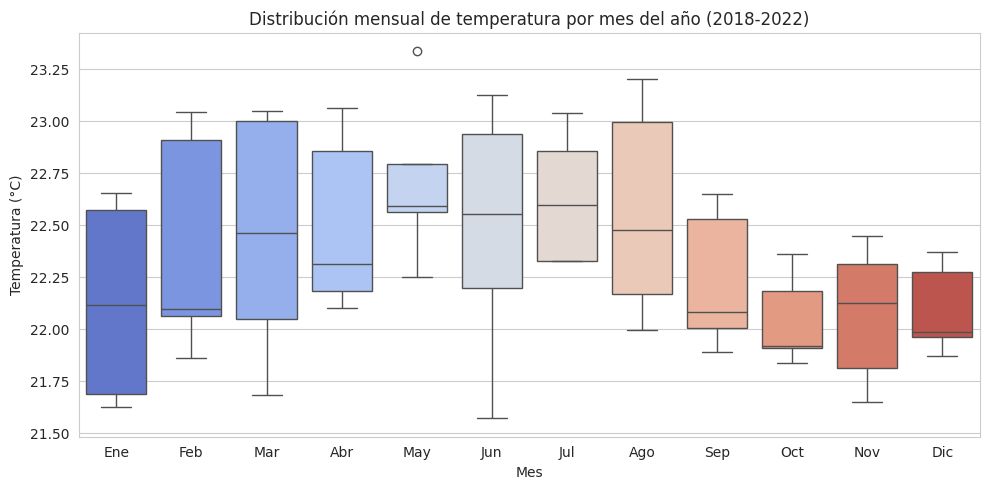

In [56]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(x='month', y='temperature_2m_mean', data=df, palette='coolwarm', ax=ax)
ax.set_title('Distribución mensual de temperatura por mes del año (2018-2022)', fontsize=12)
ax.set_xlabel('Mes')
ax.set_ylabel('Temperatura (°C)')
ax.set_xticklabels(['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
                    'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic'])
plt.tight_layout()
plt.show()

Hubo mayor dispercion de temperatura en el primer trimestre de los años

## E.11 Gráfica 9: Velocidad del viento a lo largo del tiempo

La velocidad del viento modula la dispersión de contaminantes y la sensación térmica. Detectar picos o calmas a escala mensual ayuda a vincular meteorología con episodios de alta carga de aerosoles.

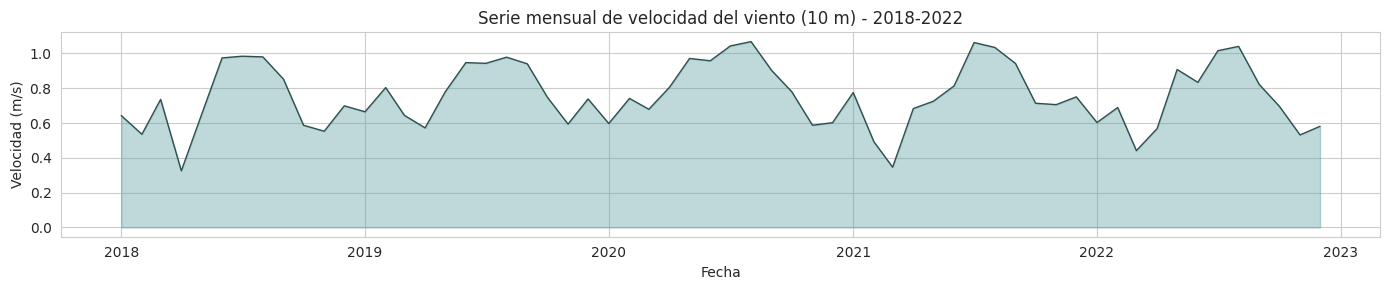

In [57]:
fig, ax = plt.subplots(figsize=(14, 3))

ax.fill_between(df['date'], df['wind_speed_mean'], color='cadetblue', alpha=0.4)
ax.plot(df['date'], df['wind_speed_mean'], color='darkslategray', linewidth=1)

ax.set_title('Serie mensual de velocidad del viento (10 m) - 2018-2022', fontsize=12)
ax.set_ylabel('Velocidad (m/s)')
ax.set_xlabel('Fecha')
plt.tight_layout()
plt.show()

La serie muestra una marcada estacionalidad en la velocidad del viento a 10 m entre 2018 y 2022, con picos anuales recurrentes cercanos a 1,0 m/s y valles mínimos que descienden hasta aproximadamente 0,3–0,4 m/s, evidenciando un patrón cíclico regular de mayor y menor intensidad eólica cada año.

## E.12 Resumen estadístico del período 2018-2022

In [58]:
summary_df = df[['temperature_2m_mean', 'dewpoint_temperature_2m_mean',
                 'wind_speed_mean', 'u_component_of_wind_10m_mean',
                 'v_component_of_wind_10m_mean']].describe().T
summary_df = summary_df[['mean', 'std', 'min', '50%', 'max']].round(2)
summary_df.columns = ['Media', 'Std', 'Min', 'Mediana', 'Max']

print("Resumen estadístico - Período 2018-2022 (valores escalados)")
display(summary_df)

# Insights rápidos
print("\n--- Insights rápidos ---")
print(f"• Meses analizados: {len(df)}")
print(f"• Temperatura media: {df['temperature_2m_mean'].mean():.1f} °C")
print(f"• Mes más cálido: {df.loc[df['temperature_2m_mean'].idxmax(), 'date'].strftime('%Y-%m')} ({df['temperature_2m_mean'].max():.1f} °C)")
print(f"• Mes más frío: {df.loc[df['temperature_2m_mean'].idxmin(), 'date'].strftime('%Y-%m')} ({df['temperature_2m_mean'].min():.1f} °C)")
print(f"• Velocidad media del viento: {df['wind_speed_mean'].mean():.1f} m/s")
print(f"• Dirección dominante del viento: {df.loc[df['wind_speed_mean'].idxmax(), 'wind_direction_mean']:.0f}° (en el mes más ventoso)")

Resumen estadístico - Período 2018-2022 (valores escalados)


,Media,Std,Min,Mediana,Max
temperature_2m_mean,22.36,0.46,21.57,22.31,23.34
dewpoint_temperature_2m_mean,19.12,0.44,18.39,19.07,20.13
wind_speed_mean,0.76,0.18,0.33,0.74,1.07
u_component_of_wind_10m_mean,0.23,0.24,-0.19,0.19,0.70
v_component_of_wind_10m_mean,-0.69,0.13,-0.93,-0.70,-0.32



--- Insights rápidos ---
• Meses analizados: 60
• Temperatura media: 22.4 °C
• Mes más cálido: 2020-05 (23.3 °C)
• Mes más frío: 2022-06 (21.6 °C)
• Velocidad media del viento: 0.8 m/s
• Dirección dominante del viento: 302° (en el mes más ventoso)


En el período 2018-2022 (60 meses), la serie mensual revela un régimen térmico muy estable, con temperatura media de 22,4 °C y baja variabilidad ( = 0,46 °C), oscilando entre un mínimo de 21,6 °C en junio de 2022 y un máximo de 23,3 °C en mayo de 2020; la temperatura de rocío promedió 19,1 °C ( = 0,44 °C), lo que evidencia una humedad ambiental sostenida con una diferencia media de ~3,2 °C entre ambas variables. Respecto al viento a 10 m, las velocidades fueron moderadas a bajas, con una media de 0,76 m/s ( = 0,18 m/s) y un pico de 1,07 m/s, predominando una dirección del noroeste (302°) caracterizada por una componente zonal u débilmente positiva (media 0,23) y una componente meridional v negativa más marcada (media -0,69), indicando un flujo dominante desde el cuadrante noroccidental durante los años analizados.